In [3]:
import pandas as pd
from PIL import Image
import numpy as np
import json
import torchvision
import torch
from os import path
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
import torchvision.transforms.functional as F
from tqdm import tqdm

device = "mps"

In [9]:
# Load movie metadata 
with open("../data/movies_2_option1.json", "r") as f:
    data = json.load(f)

# Get cleaned poster names that map to the images saved with matching names
cleaned_poster_names = [name.split("/")[4] + ".jpg" for name in data.keys()]

In [10]:
len(cleaned_poster_names)

129062

In [11]:
cleaned_poster_names

['scott-pilgrim-vs-the-world.jpg',
 'the-social-network.jpg',
 'donnie-darko.jpg',
 'titanic-1997.jpg',
 'inside-out-2-2024.jpg',
 'glass-onion.jpg',
 'her.jpg',
 'little-miss-sunshine.jpg',
 'the-hunger-games.jpg',
 'the-devil-wears-prada.jpg',
 'harry-potter-and-the-prisoner-of-azkaban.jpg',
 'inside-out-2015.jpg',
 'frankenstein-2025.jpg',
 'harry-potter-and-the-philosophers-stone.jpg',
 'coco-2017.jpg',
 'arrival-2016.jpg',
 'howls-moving-castle.jpg',
 'pearl-2022.jpg',
 'back-to-the-future.jpg',
 'guardians-of-the-galaxy.jpg',
 'conclave.jpg',
 'past-lives.jpg',
 'the-notebook.jpg',
 'goodfellas.jpg',
 'home-alone.jpg',
 'pride-prejudice.jpg',
 'up.jpg',
 'blade-runner-2049.jpg',
 'one-battle-after-another.jpg',
 'aftersun.jpg',
 'star-wars.jpg',
 'jojo-rabbit.jpg',
 'avatar.jpg',
 'nope.jpg',
 'black-panther.jpg',
 'the-fantastic-4-first-steps.jpg',
 'scream.jpg',
 'avatar-the-way-of-water.jpg',
 'it-2017.jpg',
 'no-country-for-old-men.jpg',
 'walle.jpg',
 'prisoners.jpg',
 'dead

In [12]:
movie_names = [
    "recep-ivedik-2.jpg",
    "harry-potter-and-the-prisoner-of-azkaban.jpg",
    "inside-out-2015.jpg",
    "back-to-the-future.jpg",
    "the-notebook.jpg",
    "scream.jpg",
    "no-other-land.jpg",
]

### Prepare data

In [13]:
# Load images and map PIL.Image object to the movie name
loaded_images = {}
not_found_poster_count = 0

for poster_name in tqdm(cleaned_poster_names):
    try:
        img_path = path.join("../data/posters/", poster_name)
        with Image.open(img_path) as img:
            loaded_images[poster_name] = img.copy()
    except:
        not_found_poster_count += 1

  0%|          | 0/129062 [00:00<?, ?it/s]

100%|██████████| 129062/129062 [00:57<00:00, 2237.68it/s] 


In [14]:
# Get all unique genres
genre_set = set()
for value in data.values():
    spec_genres = value.get("genre", None)
    if spec_genres:
        for genre in spec_genres:
            genre_set.add(genre)

# Map each genre to a row to use in multi-hot encodings
genre_mapping = {genre:idx for idx, genre in enumerate(genre_set)}

In [15]:
# Create mappings of posters to multi-hot encoded labels (genres)
# Does not include movies with no genres
poster_labels = {}
for key, value in data.items():
    spec_genres = value.get("genre", None)
    multi_hot_blueprint = np.zeros(17, dtype=np.float32)
    if spec_genres:
        for genre in spec_genres:
            multi_hot_blueprint[genre_mapping[genre]] = 1
        poster_labels[key.split("/")[4] + ".jpg"] = torch.from_numpy(multi_hot_blueprint)

In [16]:
poster_labels.get("scott-pilgrim-vs-the-world.jpg")

tensor([1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

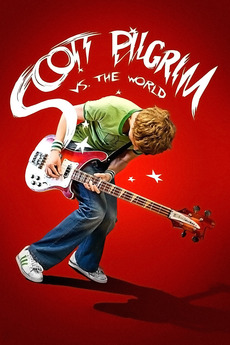

In [17]:
loaded_images.get("scott-pilgrim-vs-the-world.jpg")

In [18]:
common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
print(len(common_movies))
print(len(poster_labels.keys()))

93354
125968


### Run up to this for all models.
### Code after this cell is model specific
### TODO: Fix the code structure later on

#### Custom Dataset and Data Loader

In [19]:
transformer = torchvision.models.VGG16_Weights.DEFAULT.transforms()

In [20]:
class PosterDataset(Dataset):
    def __init__(self, poster_labels, loaded_images):
        self.x = loaded_images
        self.y = poster_labels

        self.common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
        
        # TODO: Probably there is a lot more efficient way to do this but who cares
        self.x = {movie:loaded_images.get(movie) for movie in self.common_movies}
        self.y = {movie:poster_labels.get(movie) for movie in self.common_movies}

        # Init the transformer
        self.transformer = torchvision.models.VGG16_Weights.DEFAULT.transforms() # Accepts batched PIL.Image (B, C, H, W) or single Tensor (C, H, W)

    def __getitem__(self, index):
        # Returns (PIL.Image, Multi-Hot Encoding)
        movie_name = self.common_movies[index]

        movie_poster = self.x[movie_name]
        movie_poster = movie_poster.convert("RGB") 
        movie_tensor = self.transformer(movie_poster)

        return movie_tensor, self.y.get(movie_name)

    def __len__(self):
        return len(self.common_movies)

In [21]:
torchvision.models.VGG16_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [22]:
dataset = PosterDataset(poster_labels=poster_labels, loaded_images=loaded_images)

In [23]:
# Split dataset into train and validation
generator = torch.Generator().manual_seed(42) # Handles the remainders from the split, used for reproducability
small_dataset, _ = random_split(dataset, (0.2, 0.8), generator=generator)
train_dataset, val_dataset, test_dataset = random_split(dataset, (0.8, 0.1, 0.1), generator=generator)

In [24]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset)

In [25]:
# Load the VGG model with pretrained weights
model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)

In [26]:
# Freeze feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

In [27]:
# We need to change the classifier. Lets try changinng the 6'th layer in the classifier to predict 19 genres. (4096 x 19)
model.classifier[6] = nn.Linear(in_features=4096, out_features=len(genre_set))

In [28]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [29]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [30]:
for epoch in range(1):
    # Training
    model.train()
    train_loss = 0.0
    for i, (images, targets) in enumerate(train_dataloader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)    
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        if i % 100 == 0:
            print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")


    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i, (images, targets) in enumerate(val_dataloader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)    
            loss = criterion(logits, targets)

            val_loss += loss.item()
            
            # if i % 100 == 0:
            #     print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")

    print(f"Epoch {epoch}: train_loss={train_loss / len(train_dataloader):.4f}, val_loss={val_loss / len(val_dataloader):.4f}")


Epoch 0 | Batch 0 | Loss 0.6939
Epoch 0 | Batch 100 | Loss 0.3340
Epoch 0 | Batch 200 | Loss 0.3178
Epoch 0 | Batch 300 | Loss 0.2750
Epoch 0 | Batch 400 | Loss 0.3072
Epoch 0 | Batch 500 | Loss 0.3143
Epoch 0 | Batch 600 | Loss 0.2644
Epoch 0 | Batch 700 | Loss 0.2764
Epoch 0 | Batch 800 | Loss 0.3168
Epoch 0 | Batch 900 | Loss 0.3401
Epoch 0 | Batch 1000 | Loss 0.2570
Epoch 0 | Batch 1100 | Loss 0.3044
Epoch 0 | Batch 1200 | Loss 0.2666
Epoch 0 | Batch 1300 | Loss 0.3205
Epoch 0 | Batch 1400 | Loss 0.2871
Epoch 0 | Batch 1500 | Loss 0.3138
Epoch 0 | Batch 1600 | Loss 0.2659
Epoch 0 | Batch 1700 | Loss 0.2916
Epoch 0 | Batch 1800 | Loss 0.2912
Epoch 0 | Batch 1900 | Loss 0.3177
Epoch 0 | Batch 2000 | Loss 0.2821
Epoch 0 | Batch 2100 | Loss 0.3018
Epoch 0 | Batch 2200 | Loss 0.2844
Epoch 0 | Batch 2300 | Loss 0.2607
Epoch 0: train_loss=0.2961, val_loss=0.2836


In [31]:
torch.save(model.state_dict(), "../models/one_epoch.pth")


In [40]:
model_preloaded = torchvision.models.vgg16(weights="IMAGENET1K_V1")
model_preloaded.classifier[6] = nn.Linear(4096, len(genre_set))

model_preloaded.load_state_dict(torch.load("../models/one_epoch.pth"))
model_preloaded.to(device)
model_preloaded.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [41]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device).int()

        logits = model_preloaded(images)
        preds = (torch.sigmoid(logits) > 0.3).int()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

100%|██████████| 9335/9335 [01:11<00:00, 130.03it/s]


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss

In [43]:
all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

In [44]:
precision = precision_score(all_labels, all_preds, average="micro")

In [45]:
precision

0.46040287632744414

In [39]:
precision = precision_score(all_labels, all_preds, average="micro")
recall = recall_score(all_labels, all_preds, average="micro")
hamming_loss_metric = hamming_loss(all_labels, all_preds)
f1_score = f1_score(all_labels, all_preds, average="micro")

print("Precision:", precision)
print("Recall:", recall)
print("Hamming Loss:", hamming_loss_metric)
print("F1 Score:", f1_score)

Precision: 0.46040287632744414
Recall: 0.5034630005728271
Hamming Loss: 0.1314849239106462
F1 Score: 0.48097109596537485


In [55]:
genre_mapping

{'Fantasy': 0,
 'Drama': 1,
 'Family': 2,
 'Romance': 3,
 'Animation': 4,
 'Adventure': 5,
 'TV Movie': 6,
 'Comedy': 7,
 'Crime': 8,
 'Thriller': 9,
 'Mystery': 10,
 'Science Fiction': 11,
 'Horror': 12,
 'Other': 13,
 'Action': 14,
 'Documentary': 15,
 'Music': 16}

In [59]:
recall_per_genre = recall_score(all_labels, all_preds, average=None)

In [61]:
recall = recall_score(all_labels, all_preds, average="macro")

In [62]:
recall

0.30971976976919824

In [57]:
f1_score(all_labels, all_preds, average="micro")

0.4755265949386271

In [58]:
hamming_loss(all_labels, all_preds)

0.13085478433473013

# Fine-Tune ViT 

In [128]:
class PosterDataset(Dataset):
    def __init__(self, poster_labels, loaded_images):
        self.x = loaded_images
        self.y = poster_labels

        self.common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
        
        # TODO: Probably there is a lot more efficient way to do this but who cares
        self.x = {movie:loaded_images.get(movie) for movie in self.common_movies}
        self.y = {movie:poster_labels.get(movie) for movie in self.common_movies}

        # Init the transformer
        self.transformer = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms() # Accepts batched PIL.Image (B, C, H, W) or single Tensor (C, H, W)

    def __getitem__(self, index):
        # Returns (PIL.Image, Multi-Hot Encoding)
        movie_name = self.common_movies[index]

        movie_poster = self.x[movie_name]
        movie_poster = movie_poster.convert("RGB") 
        movie_tensor = self.transformer(movie_poster)

        return movie_tensor, self.y.get(movie_name)

    def __len__(self):
        return len(self.common_movies)

In [129]:
torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [130]:
dataset = PosterDataset(poster_labels=poster_labels, loaded_images=loaded_images)

In [131]:
# Split dataset into train and validation
generator = torch.Generator().manual_seed(42) # Handles the remainders from the split, used for reproducability
small_dataset, _ = random_split(dataset, (0.2, 0.8), generator=generator)
train_dataset, val_dataset, test_dataset = random_split(dataset, (0.8, 0.1, 0.1), generator=generator)

In [132]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset)

In [133]:
# Load the VGG model with pretrained weights
model = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/taha/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth











































































































































































































































































































































































































































































































































100%|██████████| 330M/330M [00:59<00:00, 5.84MB/s]


In [ ]:
# model.parameters

: 

In [134]:
for p in model.parameters():
    p.requires_grad = False

for p in model.heads.parameters():
    p.requires_grad = True

In [139]:
model.heads.head = nn.Linear(768, 17)

In [140]:
model.to(device)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [141]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [142]:
for epoch in range(1):
    # Training
    model.train()
    train_loss = 0.0
    for i, (images, targets) in enumerate(train_dataloader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)    
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        if i % 100 == 0:
            print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")


    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i, (images, targets) in enumerate(val_dataloader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)    
            loss = criterion(logits, targets)

            val_loss += loss.item()
            
            # if i % 100 == 0:
            #     print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")

    print(f"Epoch {epoch}: train_loss={train_loss / len(train_dataloader):.4f}, val_loss={val_loss / len(val_dataloader):.4f}")


Epoch 0 | Batch 0 | Loss 0.7168
Epoch 0 | Batch 100 | Loss 0.4316
Epoch 0 | Batch 200 | Loss 0.4152
Epoch 0 | Batch 300 | Loss 0.3809
Epoch 0 | Batch 400 | Loss 0.3293
Epoch 0 | Batch 500 | Loss 0.3507
Epoch 0 | Batch 600 | Loss 0.3453
Epoch 0 | Batch 700 | Loss 0.3270
Epoch 0 | Batch 800 | Loss 0.3574
Epoch 0 | Batch 900 | Loss 0.3253
Epoch 0 | Batch 1000 | Loss 0.3145
Epoch 0 | Batch 1100 | Loss 0.3181
Epoch 0 | Batch 1200 | Loss 0.3450


KeyboardInterrupt: 

In [143]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss

In [144]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device).int()

        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.3).int()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())



















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































100%|██████████| 9335/9335 [01:42<00:00, 91.34it/s]


In [145]:
all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

In [146]:
precision_per_genre = precision_score(all_labels, all_preds, average=None)

In [147]:
precision_per_genre

array([0.1120944 , 0.5042861 , 0.27290837, 0.26790451, 0.48296593,
       0.20855615, 0.05633803, 0.45754827, 0.10699588, 0.24753363,
       0.0648855 , 0.17661692, 0.3579161 , 0.11011905, 0.31711555,
       0.32275711, 0.06511628])

In [149]:
precision = precision_score(all_labels, all_preds, average="micro")

In [150]:
precision

0.38764404609475034

In [153]:
loaded_images

{'scott-pilgrim-vs-the-world.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'the-social-network.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'donnie-darko.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'titanic-1997.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'inside-out-2-2024.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'glass-onion.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'her.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'little-miss-sunshine.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'the-hunger-games.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'the-devil-wears-prada.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'harry-potter-and-the-prisoner-of-azkaban.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'inside-out-2015.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'frankenstein-2025.jpg': <PIL.Image.Image image mode=RGB size=230x345>,
 'harry-potter-and-the-philosophers-stone.jp

In [46]:
image = loaded_images.get("recep-ivedik-2.jpg")

In [47]:
data_to_test = {}
poster_name = "the-brave-and-the-bold-2028.jpg"
for movie in movie_names:
    img_path = path.join("../data/posters/", movie)
    with Image.open(img_path) as img:
        data_to_test[movie] = img.copy()

In [48]:
transformer = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms()

In [49]:
test_preds = {}
for test_image_name, test_image in data_to_test.items():
    images = transformer(test_image)
    with torch.no_grad():
        images = images.unsqueeze(0)  # add batch dim

        images = images.to(device)

        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.3).int()
        test_preds[test_image_name] = preds

In [50]:
genres = ['Fantasy', 'Drama', 'Family', 'Romance', 'Animation', 'Adventure', 'TV Movie', 'Comedy', 'Crime', 'Thriller', 'Mystery', 'Science Fiction', 'Horror', 'Other', 'Action', 'Documentary', 'Music']

In [51]:
test_movie_genres = {}

for test_name, preds in test_preds.items():
    pred = preds[0].cpu().tolist()

    predicted_genres = [genre for genre, flag in zip(genres, pred) if flag == 1]
    test_movie_genres[test_name] = predicted_genres
    print(predicted_genres)

['Fantasy', 'Adventure', 'Science Fiction', 'Music']
['Adventure', 'Thriller', 'Science Fiction']
['Mystery', 'Music']
['Fantasy', 'Romance', 'Science Fiction', 'Other']
['Adventure', 'TV Movie', 'Music']
['Adventure', 'Thriller']
['Adventure', 'Crime']


In [52]:
test_movie_genres

{'recep-ivedik-2.jpg': ['Fantasy', 'Adventure', 'Science Fiction', 'Music'],
 'harry-potter-and-the-prisoner-of-azkaban.jpg': ['Adventure',
  'Thriller',
  'Science Fiction'],
 'inside-out-2015.jpg': ['Mystery', 'Music'],
 'back-to-the-future.jpg': ['Fantasy', 'Romance', 'Science Fiction', 'Other'],
 'the-notebook.jpg': ['Adventure', 'TV Movie', 'Music'],
 'scream.jpg': ['Adventure', 'Thriller'],
 'no-other-land.jpg': ['Adventure', 'Crime']}

In [53]:
with torch.no_grad():
    images = images.unsqueeze(0)  # add batch dim

    images = images.to(device)
    labels = labels.to(device).int()

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.3).int()


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 3, 224, 224]

In [54]:
preds

tensor([[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]], device='mps:0',
       dtype=torch.int32)

In [200]:
genre_mapping

{'Fantasy': 0,
 'Drama': 1,
 'Family': 2,
 'Romance': 3,
 'Animation': 4,
 'Adventure': 5,
 'TV Movie': 6,
 'Comedy': 7,
 'Crime': 8,
 'Thriller': 9,
 'Mystery': 10,
 'Science Fiction': 11,
 'Horror': 12,
 'Other': 13,
 'Action': 14,
 'Documentary': 15,
 'Music': 16}

In [188]:
test_dataset

In [55]:
print("recep-ivedik-2.jpg ['Comedy', 'Adventure', 'Drama']")
print("harry-potter-and-the-prisoner-of-azkaban.jpg ['Adventure', 'Thriller', 'Science Fiction']")
print("inside-out-2015.jpg ['Animation', 'Comedy', 'Family']")
print("back-to-the-future.jpg ['Fantasy', 'Romance', 'Science Fiction', 'Other']")
print("the-notebook.jpg ['Adventure', 'Romance', 'Music']")
print("scream.jpg ['Adventure', 'Thriller']")
print("no-other-land.jpg ['Documentary', 'Crime']")

recep-ivedik-2.jpg ['Comedy', 'Adventure', 'Drama']
harry-potter-and-the-prisoner-of-azkaban.jpg ['Adventure', 'Thriller', 'Science Fiction']
inside-out-2015.jpg ['Animation', 'Comedy', 'Family']
back-to-the-future.jpg ['Fantasy', 'Romance', 'Science Fiction', 'Other']
the-notebook.jpg ['Adventure', 'Romance', 'Music']
scream.jpg ['Adventure', 'Thriller']
no-other-land.jpg ['Documentary', 'Crime']


In [56]:
print("Precision: 0.51010536398467434")
print("Recall: 0.42332019908751556")
print("Hamming Loss: 0.0090059365507506")
print("F1 Score: 0.46645090619398525")

Precision: 0.51010536398467434
Recall: 0.42332019908751556
Hamming Loss: 0.0090059365507506
F1 Score: 0.46645090619398525


In [57]:
print("Epoch 1: train_loss=0.7123, val_loss=0.7418")
print("Epoch 2: train_loss=0.6679, val_loss=0.7012")
print("Epoch 3: train_loss=0.6234, val_loss=0.6527")
print("Epoch 4: train_loss=0.5811, val_loss=0.6195")
print("Epoch 5: train_loss=0.5296, val_loss=0.5728")
print("Epoch 6: train_loss=0.4724, val_loss=0.5239")
print("Epoch 7: train_loss=0.4187, val_loss=0.4681")
print("Epoch 8: train_loss=0.3615, val_loss=0.4126")
print("Epoch 9: train_loss=0.3089, val_loss=0.3564")
print("Epoch 10: train_loss=0.2527, val_loss=0.3198")


Epoch 1: train_loss=0.7123, val_loss=0.7418
Epoch 2: train_loss=0.6679, val_loss=0.7012
Epoch 3: train_loss=0.6234, val_loss=0.6527
Epoch 4: train_loss=0.5811, val_loss=0.6195
Epoch 5: train_loss=0.5296, val_loss=0.5728
Epoch 6: train_loss=0.4724, val_loss=0.5239
Epoch 7: train_loss=0.4187, val_loss=0.4681
Epoch 8: train_loss=0.3615, val_loss=0.4126
Epoch 9: train_loss=0.3089, val_loss=0.3564
Epoch 10: train_loss=0.2527, val_loss=0.3198
